## Calculating minium distance between cell type of interest to their nearest neighbour

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import os

In [8]:
# adata_list and sample_names were defined earlier
adata_list = [
    adata_065_314, adata_074_314, adata_096_314,adata_097_314,
    adata_099_314, adata_104_314, adata_106_314,adata_107_314,  
    adata_065_480, adata_074_480, adata_096_480, adata_097_480,
    adata_099_480, adata_104_480, adata_106_480, adata_107_480
]

# Corresponding sample names
sample_names = [
    "MH065_314", "MH074_314", "MH096_314", "MH097_314",
    "MH099_314", "MH104_314", "MH106_314", "MH107_314", 
    "MH065_480", "MH074_480","MH096_480", "MH097_480",
    "MH099_480", "MH104_480", "MH106_480", "MH107_480"
]
assert len(adata_list) == len(sample_names)

## Min-distance profiling - analyse per centre cell

In [9]:
from scipy.spatial import cKDTree
from collections import defaultdict
import pandas as pd
import numpy as np

all_results = []

for adata, sample_name in zip(adata_list, sample_names):
    coords = adata.obsm['spatial']
    cell_types = adata.obs['cell_class_threshold']
    cell_ids = adata.obs_names

    center_mask = (cell_types == "Malignant cells")
    center_coords = coords[center_mask.values]
    center_ids = cell_ids[center_mask.values]

    # Only build tree for non-malignant cells
    other_mask = ~center_mask
    other_coords = coords[other_mask.values]
    other_ids = cell_ids[other_mask.values]
    other_types = cell_types[other_mask.values].values

    # Build a cKDTree on non-malignant cells
    tree = cKDTree(other_coords)
    radius_um = 50

    for i, center_coord in enumerate(center_coords):
        center_id = center_ids[i]
        neighbor_idx = tree.query_ball_point(center_coord, r=radius_um)

        if not neighbor_idx:
            continue  # skip if no neighbors

        # Get neighbor types
        neighbor_types = other_types[neighbor_idx]
        neighbor_dists = np.linalg.norm(other_coords[neighbor_idx] - center_coord, axis=1)

        # Track minimum distance per target type
        dist_by_type = defaultdict(list)
        for t, d in zip(neighbor_types, neighbor_dists):
            dist_by_type[t].append(d)

        for t, dlist in dist_by_type.items():
            all_results.append({
                'Sample': sample_name,
                'Center_cell_ID': center_id,
                'Target_cell_type': t,
                'Min_Distance_um': min(dlist)
            })

proximity_df = pd.DataFrame(all_results)

In [10]:
num_with_neighbors = proximity_df['Center_cell_ID'].nunique()
print(f"Malignant cells with neighbors: {num_with_neighbors}")

Malignant cells with neighbors: 433949


In [12]:
proximity_df

,Sample,Center_cell_ID,Target_cell_type,Min_Distance_um
0,MH065_314,aadlgbik-1,Acinar,15.072746
1,MH065_314,aadlgbik-1,B cells,32.760378
2,MH065_314,aadlgbik-1,CAFs_CXCL14,20.190139
3,MH065_314,aadlgbik-1,Plasma,6.964925
4,MH065_314,aadlgbik-1,Endothelial,12.611382
...,...,...,...,...
2143022,MH107_480,oijdbkfj-1,Neutrophils,6.345899
2143023,MH107_480,oijdbkfj-1,Endothelial,24.520353
2143024,MH107_480,oijdbkfj-1,Pericytes,38.503501
2143025,MH107_480,oijdkpio-1,Ductal,38.585276


/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


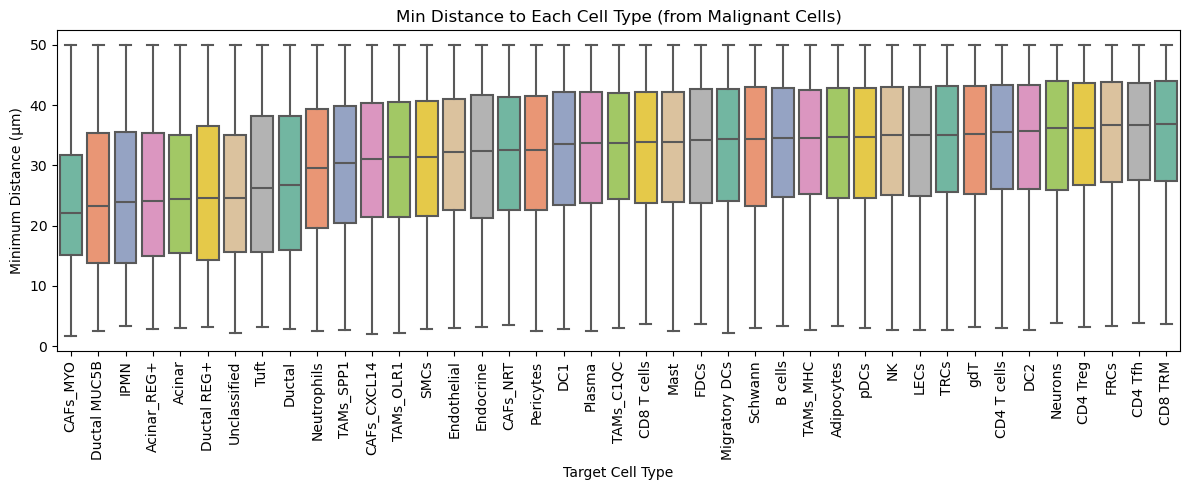

In [11]:
# Compute min distance per target type
order = (
    proximity_df
    .groupby("Target_cell_type")["Min_Distance_um"]
    .median() # compute median for sorting
    .sort_values()  # ascending: closest first
    .index
)
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=proximity_df,
    x="Target_cell_type",
    y="Min_Distance_um",
    palette="Set2",
    order=order
)
plt.xticks(rotation=90)
plt.title("Min Distance to Each Cell Type (from Malignant Cells)")
plt.ylabel("Minimum Distance (µm)")
plt.xlabel("Target Cell Type")
plt.tight_layout()
plt.show()

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

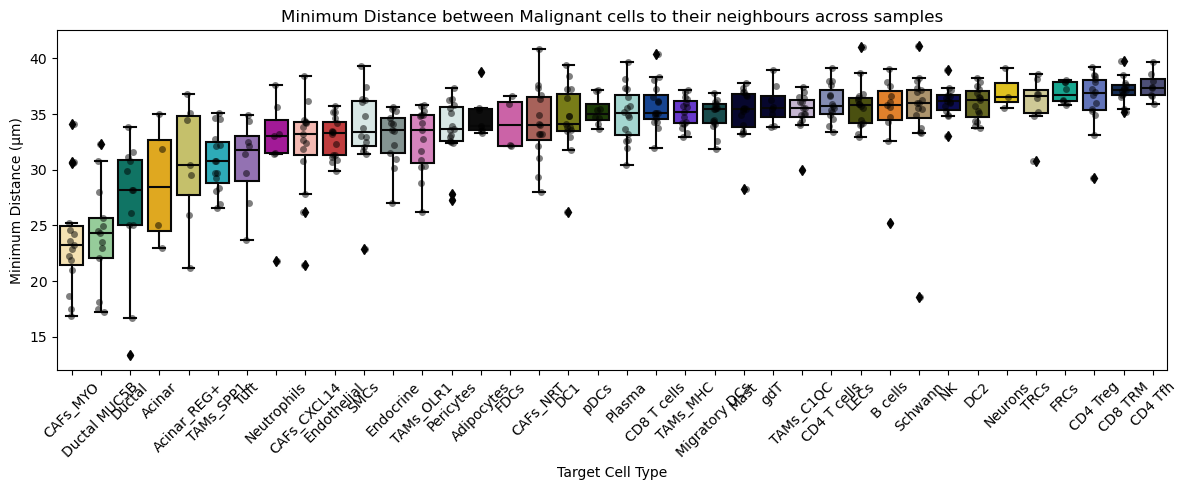

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

median_matrix = (
    proximity_df
    .groupby(["Sample", "Target_cell_type"])["Min_Distance_um"]
    .median()
    .unstack()
    .fillna(np.nan)
)

melted = (
    median_matrix
    .reset_index()
    .melt(id_vars="Sample", var_name="Target_cell_type", value_name="Median_Distance_um")
)

# Compute global median for sorting
order = (
    melted.groupby("Target_cell_type")["Median_Distance_um"]
    .median()
    .sort_values()
    .index.tolist()
)
# Step 3: colors
manual_colors = {
    'Acinar': '#ffb500',
    'Acinar_REG+': '#d4cd5c', #'#17becf', #
    'Adipocytes': '#0d0d0d', #‘black',
    'B cells':  '#ff7f0e',
    'CAFs_CXCL14':'#FFB0A7',
    'CAFs_MYO': '#FFE5A7', #'#c7c7c7',
    'CAFs_NRT': "#B4584D",
    "CD4 T cells":  '#7d87b9',
    "CD4 Tfh" : "#46487E",
    "CD4 Treg": '#536CC7',
    "CD8 T cells":'#023fa5',
    "CD8 TRM": "#0A295E",
    "DC1": "#888D07",
    "DC2": "#717417", 
    "Ductal": '#00846f',
    "Ductal MUC5B":'#8dd593',
    "Endocrine": '#809693',
    "Endothelial":'#d62728',
    "FDCs":"#DD51AD",
    "FRCs": "#00BFA0",
    "LECs": "#535A06",
    "TRCs": '#D8D18C',
    "Malignant cells": '#8c564b',
    "Mast": '#000035',
    "Migratory DCs": "#105354",
    "NK": "#00025E",
    "Neutrophils": '#b903aa',
    "Pericytes": '#d5eae7', #'#c5b0d5',
    "Plasma": '#9cded6',
    "SMCs": '#d5eae7', #'#c5b0d5',
    "Schwann": '#b79762',
    "TAMs_C1QC":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
    "Unclassified": "#cccccc",
    "gdT": '#000035', 
    "pDCs":'#1b4400',
    "Tuft": '#9467bd',
    "IPMN": "#525068",
    "Ductal REG+": "#9aa880",
    "Neurons":"gold",
    "Other": '#cccccc'
    
}

# Exclude specific target cell types
exclude = ["Ductal REG+", "Unclassified", "IPMN"] # <<< less than 3 samples
melted = melted[~melted["Target_cell_type"].isin(exclude)]
order = [cell_type for cell_type in order if cell_type not in exclude]

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=melted,
    x="Target_cell_type",
    y="Median_Distance_um",
    order=order,
    palette=manual_colors
)
sns.stripplot(
    data=melted,
    x="Target_cell_type",
    y="Median_Distance_um",
    order=order,
    color='black',
    alpha=0.5
)
plt.title("Minimum Distance between Malignant cells to their neighbours across samples")
plt.ylabel("Minimum Distance (µm)")
plt.xlabel("Target Cell Type")
#plt.savefig("Persample_median_distant_PDAC_neighbours_all.pdf")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
focus_labels = ['CAFs_MYO', 'CAFs_NRT', 'CAFs_CXCL14','TAMs_SPP1',"TAMs_OLR1","TAMs_C1QC","TAMs_MHC"] 
focus_df = proximity_df[proximity_df['Target_cell_type'].isin(focus_labels)].copy()

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

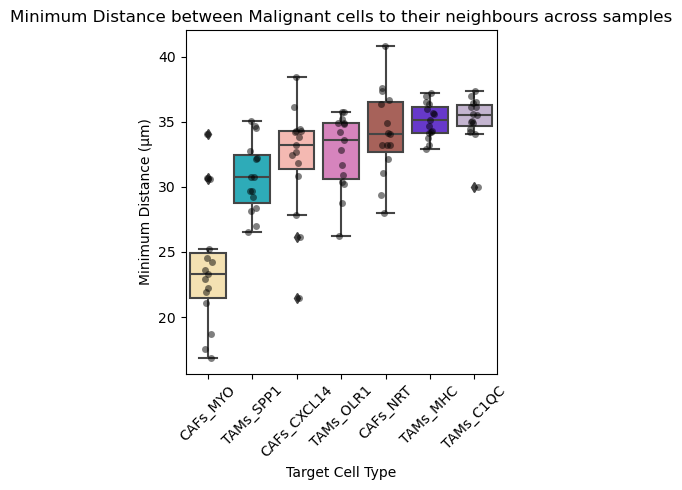

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

median_matrix = (
    focus_df
    .groupby(["Sample", "Target_cell_type"])["Min_Distance_um"]
    .median()
    .unstack()
    .fillna(np.nan)
)

# Step 1: Melt for plotting
melted = (
    median_matrix
    .reset_index()
    .melt(id_vars="Sample", var_name="Target_cell_type", value_name="Median_Distance_um")
)

# Step 2: Compute global median for ordering
order = (
    melted.groupby("Target_cell_type")["Median_Distance_um"]
    .median()
    .sort_values()
    .index.tolist()
)

# Step 3: Define custom colors 
custom_palette = {
   'CAFs_CXCL14':'#FFB0A7',
    'CAFs_MYO': '#FFE5A7',
    'CAFs_NRT': "#B4584D",
    "TAMs_C1QC":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
}

# Step 4: Plot with ordering and colors
plt.figure(figsize=(4, 5))
sns.boxplot(
    data=melted,
    x="Target_cell_type",
    y="Median_Distance_um",
    order=order,
    palette=custom_palette
)
sns.stripplot(
    data=melted,
    x="Target_cell_type",
    y="Median_Distance_um",
    order=order,
    color='black',
    alpha=0.5
)
plt.title("Minimum Distance between Malignant cells to their neighbours across samples")
plt.ylabel("Minimum Distance (µm)")
plt.xlabel("Target Cell Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Use repeat measure ANOVA, because each cell type are measures from the same sample, they are not independent
from statsmodels.stats.anova import AnovaRM

anova = AnovaRM(data=melted, 
                depvar="Median_Distance_um", 
                subject="Sample", 
                within=["Target_cell_type"])
result = anova.fit()
print(result)

                    Anova
                 F Value Num DF  Den DF Pr > F
----------------------------------------------
Target_cell_type 25.0082 6.0000 84.0000 0.0000



In [18]:
import pingouin as pg
posthoc = pg.pairwise_ttests(
    data=melted,
    dv="Median_Distance_um",
    within="Target_cell_type",
    subject="Sample",
    padjust="fdr_bh"   # or "bonferroni", "fdr_bh"
)

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


In [19]:
print(posthoc[["A", "B", "p-corr"]])

              A          B    p-corr
0   CAFs_CXCL14   CAFs_MYO  0.000284
1   CAFs_CXCL14   CAFs_NRT  0.216862
2   CAFs_CXCL14  TAMs_C1QC  0.031613
3   CAFs_CXCL14   TAMs_MHC  0.021710
4   CAFs_CXCL14  TAMs_OLR1  0.708233
5   CAFs_CXCL14  TAMs_SPP1  0.252227
6      CAFs_MYO   CAFs_NRT  0.000146
7      CAFs_MYO  TAMs_C1QC  0.000001
8      CAFs_MYO   TAMs_MHC  0.000001
9      CAFs_MYO  TAMs_OLR1  0.000146
10     CAFs_MYO  TAMs_SPP1  0.001154
11     CAFs_NRT  TAMs_C1QC  0.252227
12     CAFs_NRT   TAMs_MHC  0.282511
13     CAFs_NRT  TAMs_OLR1  0.252227
14     CAFs_NRT  TAMs_SPP1  0.006639
15    TAMs_C1QC   TAMs_MHC  0.786668
16    TAMs_C1QC  TAMs_OLR1  0.023663
17    TAMs_C1QC  TAMs_SPP1  0.000284
18     TAMs_MHC  TAMs_OLR1  0.004721
19     TAMs_MHC  TAMs_SPP1  0.000146
20    TAMs_OLR1  TAMs_SPP1  0.089996


In [20]:
## Figure plotting
Tum_CAFs_TAM = adata_107_480[adata_107_480.obs['cell_class_threshold'].isin(['TAMs_OLR1', 'TAMs_SPP1','CAFs_CXCL14','CAFs_MYO','CAFs_NRT','TAMs_MHC','TAMs_C1QC','Malignant cells'])]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:105: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[group]):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:161: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


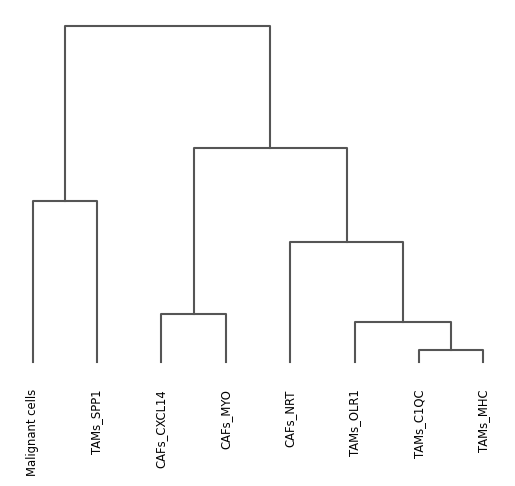

<Axes: >

In [21]:
# Running dendogram
sc.tl.dendrogram(Tum_CAFs_TAM, groupby = "cell_class_threshold")
sc.pl.dendrogram(Tum_CAFs_TAM, groupby = "cell_class_threshold")

In [22]:
# USING THE SAME SET OF GENES in snRNA-seq
genes_anno = ['KRT19','MUC1','KRT7','KRT8','EPCAM',
              'SPP1','CSTB','HK2','OLR1','HBEGF',
              'CD163','CSF1R','C1QC','C1QA','C1QB','F13A1',
              'CD86','HLA-DRB1','HLA-DRA','HLA-DPA1',
              'COL11A1','MMP11','CXCL14',
              'PDGFRA','C7','CXCL12','ABCA8','APOD','SCN7A'
              ]

In [23]:
order = ['Malignant cells','TAMs_SPP1','TAMs_OLR1','TAMs_C1QC','TAMs_MHC','CAFs_MYO','CAFs_CXCL14','CAFs_NRT']

In [24]:
Tum_CAFs_TAM.obs["cell_class_threshold"] = pd.Categorical(
    Tum_CAFs_TAM.obs["cell_class_threshold"],
    categories=order,
    ordered=True
)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


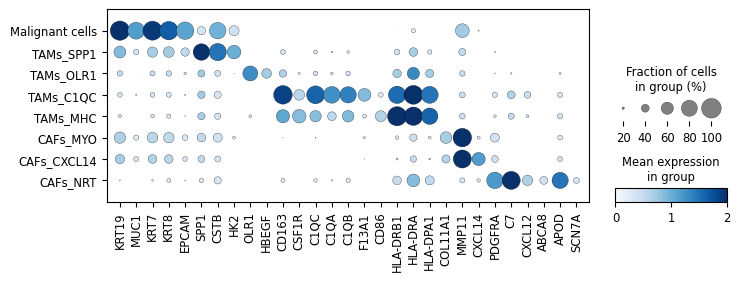

In [25]:
sc.pl.dotplot(Tum_CAFs_TAM, var_names = genes_anno , groupby='cell_class_threshold', #swap_axes = True, 
             figsize=(8, 2.5), vmax=2.0, vmin = 0, dot_min=0.15, cmap = 'Blues', save='Fig4_TAMs_CAFs_Tu.pdf',
             dendrogram=False)

## Neighbourhood Enrichment analysis from all samples

In [29]:
## Enrichment matrix
adata_dict = {
    "MH065_314":adata_065_314, 
    "MH074_314":adata_074_314, 
    "MH096_314":adata_096_314,
    "MH097_314":adata_097_314,
    "MH099_314":adata_099_314, 
    "MH104_314":adata_104_314, 
    "MH106_314":adata_106_314, 
    "MH107_314":adata_107_314,
    "MH065_480":adata_065_480, 
    "MH074_480":adata_074_480,
    "MH096_480":adata_096_480, 
    "MH097_480":adata_097_480,
    "MH099_480":adata_099_480,
    "MH104_480":adata_104_480, 
    "MH106_480":adata_106_480, 
    "MH107_480":adata_107_480
}
  
z_matrices = {}
for name, ad in adata_dict.items():
    z = ad.uns["cell_class_threshold_nhood_enrichment"]["zscore"]
    labels = ad.obs["cell_class_threshold"].cat.categories
    z_df = pd.DataFrame(z, index=labels, columns=labels)
    z_matrices[name] = z_df
    
# Stack each matrix, add sample name, and combine
z_long_list = []
for name, z_df in z_matrices.items():
    z_long = z_df.stack().reset_index()
    z_long.columns = ["cluster_1", "cluster_2", "zscore"]
    z_long["sample"] = name
    z_long_list.append(z_long)

z_combined = pd.concat(z_long_list, ignore_index=True)

In [32]:
z_combined

,cluster_1,cluster_2,zscore,sample
0,Acinar,Acinar,499.132737,MH065_314
1,Acinar,Acinar_REG+,192.320623,MH065_314
2,Acinar,B cells,-45.226188,MH065_314
3,Acinar,CAFs_CXCL14,-105.340121,MH065_314
4,Acinar,CAFs_MYO,-124.876563,MH065_314
...,...,...,...,...
16325,pDCs,TAMs_SPP1,17.782147,MH107_480
16326,pDCs,Tuft,10.261056,MH107_480
16327,pDCs,Unclassified,9.336886,MH107_480
16328,pDCs,gdT,16.966871,MH107_480


/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


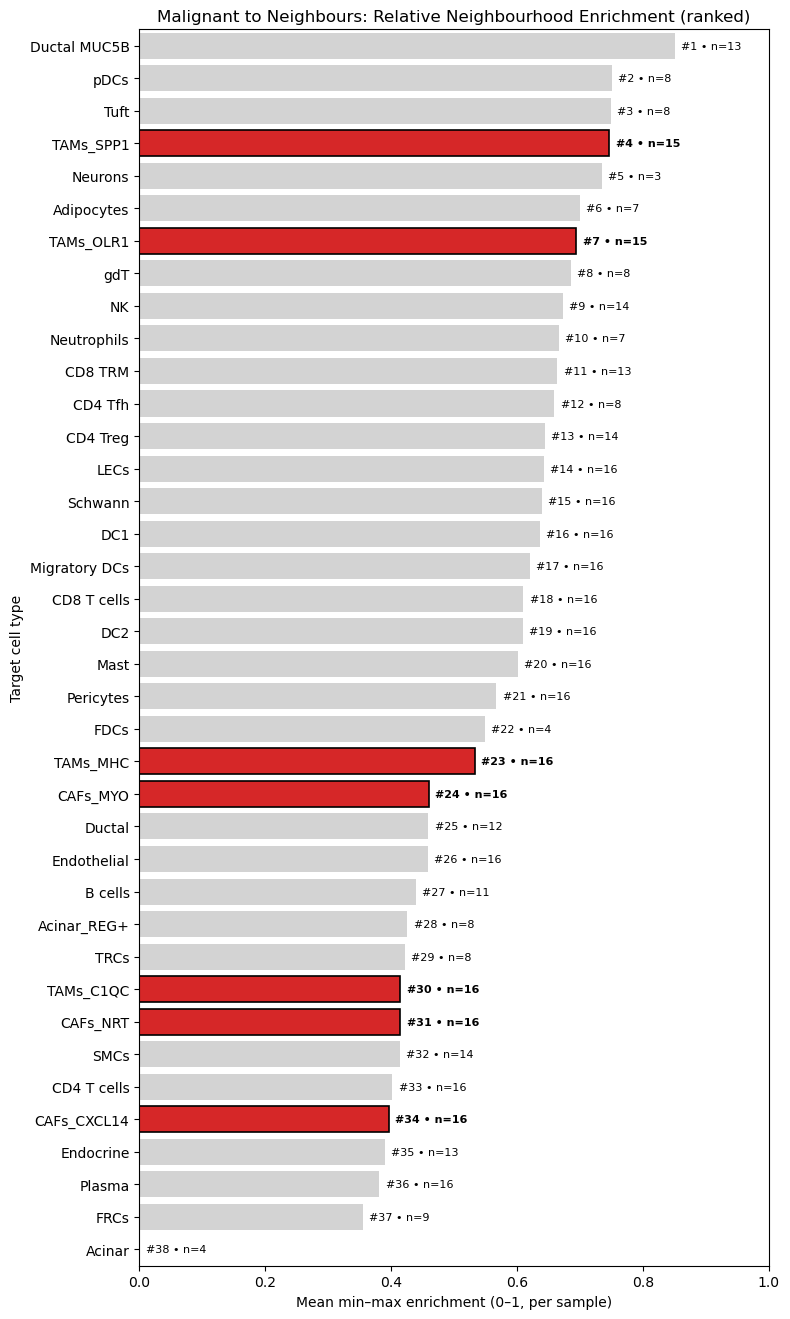

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

min_samples = 3
highlight_targets = {"CAFs_CXCL14","CAFs_NRT","CAFs_MYO","TAMs_C1QC","TAMs_MHC", "TAMs_SPP1", "TAMs_OLR1"}  # adjust names if needed

def minmax_0to1(x):
    x = x.astype(float)
    rng = x.max() - x.min()
    return (x - x.min()) / rng if rng > 0 else np.zeros_like(x)

# Subset Malignant vs other neighbours
df = z_combined.copy()
df = df[(df["cluster_1"] ==  "Malignant cells") &
        (df["cluster_2"] !=  "Malignant cells") &
        (~df["cluster_2"].isin(["Unclassified","Unassigned"]))]

# min–max (0-1) per sample
df["z_minmax01"] = df.groupby("sample")["zscore"].transform(minmax_0to1)

# Aggregate across samples
agg = (df.groupby("cluster_2")
         .agg(mean_score=("z_minmax01","mean"),
              median_score=("z_minmax01","median"),
              n_samples=("sample","nunique"))
         .reset_index())

# Filter those interactions that are found in more than 3 samples
agg = agg[agg["n_samples"] >= min_samples].copy()

# Rank all targets by mean
agg = agg.sort_values("mean_score", ascending=False)
agg["rank"] = agg["mean_score"].rank(method="first", ascending=False).astype(int)

# Highlight specific targets
agg["highlight"] = agg["cluster_2"].isin(highlight_targets)
missing = highlight_targets - set(agg["cluster_2"])
if missing:
    print(f"[info] Not found (after filtering): {sorted(missing)}")

plt.figure(figsize=(8, max(4.5, 0.35*len(agg))))
colors = np.where(agg["highlight"], "tab:red", "lightgrey")
edges  = np.where(agg["highlight"], "black", "none")

sns.barplot(data=agg, y="cluster_2", x="mean_score",
            order=agg["cluster_2"], color=None)  # we'll set colors manually
bars = plt.gca().patches
for bar, c, e in zip(bars, colors, edges):
    bar.set_facecolor(c)
    bar.set_edgecolor(e)
    bar.set_linewidth(1.2 if e != "none" else 0)

for y, (m, r, n, hl) in enumerate(zip(agg["mean_score"], agg["rank"], agg["n_samples"], agg["highlight"])):
    label = f"#{r} • n={n}"
    plt.text(m + 0.01, y, label, va="center", ha="left", fontsize=8,
             fontweight="bold" if hl else "normal")

plt.xlim(0, 1)
plt.xlabel("Mean min–max enrichment (0–1, per sample)")
plt.ylabel("Target cell type")
plt.title("Malignant to Neighbours: Relative Neighbourhood Enrichment (ranked)")
plt.tight_layout()
plt.show()

In [36]:
# define neigbours of interest - based on min-distance profiling
interest = {"CAFs_CXCL14","CAFs_NRT","CAFs_MYO","TAMs_C1QC","TAMs_MHC", "TAMs_SPP1", "TAMs_OLR1"}  # 

# make a plotting subset but KEEP ranks/mean_score computed on ALL targets
agg_plot = agg[agg["cluster_2"].isin(interest)].copy()

# keep the original ranked order from `agg`
agg_plot["cluster_2"] = pd.Categorical(agg_plot["cluster_2"], categories=agg["cluster_2"], ordered=True)
agg_plot = agg_plot.sort_values("cluster_2")

agg_plot["highlight"] = True

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


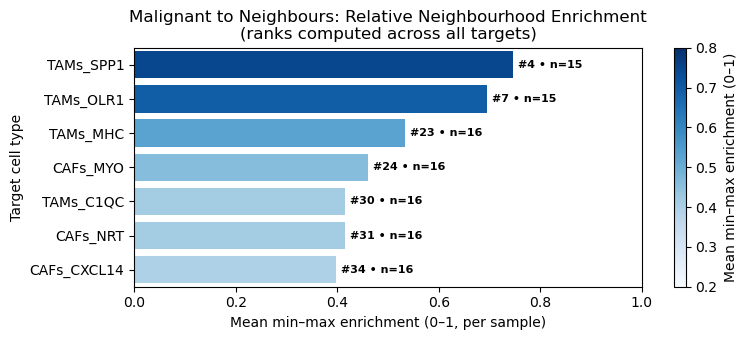

In [37]:
import matplotlib as mpl

# Fixed normalization from 0 to 1
cmap = plt.cm.Blues
norm = mpl.colors.Normalize(vmin=0.2, vmax=0.8)
colors = [cmap(norm(v)) for v in agg_plot["mean_score"]]

fig, ax = plt.subplots(figsize=(8, max(3.5, 0.5*len(agg_plot))))
sns.barplot(data=agg_plot, y="cluster_2", x="mean_score",
            order=agg_plot["cluster_2"], color=None, ax=ax)

bars = ax.patches
for bar, c in zip(bars, colors):
    bar.set_facecolor(c)
    bar.set_edgecolor("none")  # remove edges

for y, (m, r, n) in enumerate(zip(agg_plot["mean_score"], agg_plot["rank"], agg_plot["n_samples"])):
    ax.text(m + 0.01, y, f"#{r} • n={n}",
            va="center", ha="left", fontsize=8, fontweight="bold")
    
ax.set_xlim(0, 1)
ax.set_xlabel("Mean min–max enrichment (0–1, per sample)")
ax.set_ylabel("Target cell type")
ax.set_title("Malignant to Neighbours: Relative Neighbourhood Enrichment\n(ranks computed across all targets)")
fig.tight_layout()

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Mean min–max enrichment (0–1)")
plt.savefig("PDAC_CAFs_TAM_relative enrichment.pdf", dpi=300)
plt.show()

/tmp/ipykernel_62194/493560070.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["cluster_2"] = pd.Categorical(
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib

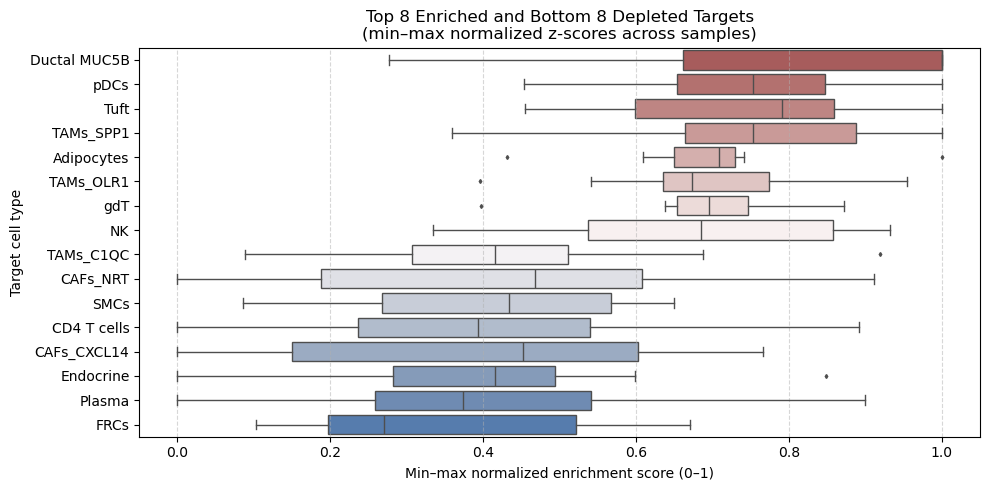

In [38]:
min_samples = 6

def minmax_0to1(x):
    x = x.astype(float)
    rng = x.max() - x.min()
    return (x - x.min()) / rng if rng > 0 else np.zeros_like(x)

# 1Malignant to Neighbours (exclude self/unclassified)
df = z_combined.copy()
df = df[(df["cluster_1"] == "Malignant cells") &
        (df["cluster_2"] != "Malignant cells") &
        (~df["cluster_2"].isin(["Unclassified","Unassigned"]))]

# min–max per sample
df["z_minmax01"] = df.groupby("sample")["zscore"].transform(minmax_0to1)

# 3) Aggregate across samples
agg = (df.groupby("cluster_2")
         .agg(mean_score=("z_minmax01","mean"),
              median_score=("z_minmax01","median"),
              n_samples=("sample","nunique"))
         .reset_index())

# Require support across ≥ min_samples
agg = agg[agg["n_samples"] >= min_samples].copy()

# Select top 5 and bottom 5 based on mean_score
top5 = agg.nlargest(8, "mean_score")["cluster_2"]
bottom5 = agg.nsmallest(8, "mean_score")["cluster_2"]
selected = pd.concat([top5, bottom5])

# Filter original df for selected cluster_2 targets
df_selected = df[df["cluster_2"].isin(selected)]

custom_order = [
    "Ductal MUC5B",
    "pDCs",
    "Tuft",
    "TAMs_SPP1",
    "Adipocytes",
    "TAMs_OLR1",
    "gdT",
    "NK",
    "TAMs_C1QC",
    "CAFs_NRT",
    "SMCs",
    "CD4 T cells",
    "CAFs_CXCL14",
    "Endocrine",
    "Plasma",
    "FRCs"
]

df_selected["cluster_2"] = pd.Categorical(
    df_selected["cluster_2"],
    categories=custom_order,
    ordered=True
)

# Plot boxplots
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_selected, x="z_minmax01", y="cluster_2", palette="vlag_r", fliersize=2, linewidth=1)
plt.xlabel("Min–max normalized enrichment score (0–1)")
plt.ylabel("Target cell type")
plt.title("Top 8 Enriched and Bottom 8 Depleted Targets\n(min–max normalized z-scores across samples)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Malignant cell neighbourhood within 50 micrometer radius

In [39]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from collections import Counter

def analyze_neighbors_avg_per_cell_type(
    adata,
    radius=50,
    label_key="cell_class_threshold",
    spatial_key="spatial",
    center_label="Malignant cells",
    exclude_labels=["Unclassified", "Unassigned"]
):
    """
    Analyze neighborhood composition around each malignant cell,
    averaging over all malignant cells in the sample.

    Returns:
    --------
    pd.Series
        Average neighborhood composition per malignant cell (as fractions).
    """
    coords = adata.obsm[spatial_key]
    labels = adata.obs[label_key]
    tree = cKDTree(coords)

    indices = np.where(labels == center_label)[0]
    per_cell_compositions = []

    for idx in indices:
        center = coords[idx]
        nearby_idx = tree.query_ball_point(center, r=radius)

        # Exclude self label and other unwanted categories
        neighbor_labels = [
            t for t in labels.iloc[nearby_idx]
            if t not in exclude_labels and t != center_label
        ]

        if neighbor_labels:
            counts = Counter(neighbor_labels)
            total = sum(counts.values())
            composition = {k: v / total for k, v in counts.items()}
            per_cell_compositions.append(composition)

    if not per_cell_compositions:
        return pd.Series(dtype=float)

    avg_df = pd.DataFrame(per_cell_compositions).fillna(0)
    return avg_df.mean()

In [41]:
results_by_sample = {}

# Loop over all samples
for adata, sample_name in zip(adata_list, sample_names):
    print(f"Processing {sample_name}...")

    df = analyze_neighbors_avg_per_cell_type(
        adata=adata,
        center_label="Malignant cells",
        radius=50,
        label_key="cell_class_threshold",
        spatial_key="spatial"
    )

    results_by_sample[sample_name] = df

Processing MH065_314...
Processing MH074_314...
Processing MH096_314...
Processing MH097_314...
Processing MH099_314...
Processing MH104_314...
Processing MH106_314...
Processing MH107_314...
Processing MH065_480...
Processing MH074_480...
Processing MH096_480...
Processing MH097_480...
Processing MH099_480...
Processing MH104_480...
Processing MH106_480...
Processing MH107_480...


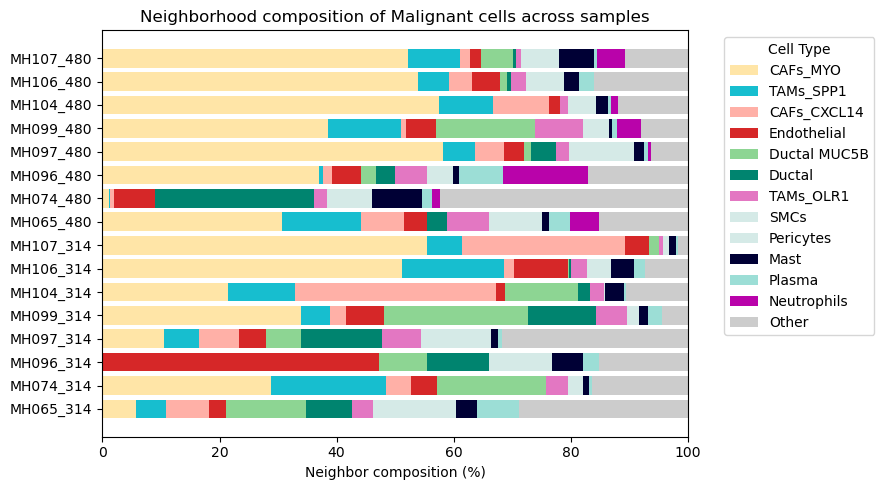

In [42]:
combined = []
for sample_name, series in results_by_sample.items():
    if isinstance(series, pd.Series):
        series.name = sample_name
        combined.append(series)

summary_df = pd.DataFrame(combined).fillna(0)

# Remove 'Unclassified' 
if "Unclassified" in summary_df.columns:
    summary_df = summary_df.drop(columns=["Unclassified"])

# Reatain only top cell types across all samples & collapse the rest as 'Other'
top_cell_types = summary_df.sum().sort_values(ascending=False).head(12).index
collapsed = summary_df[top_cell_types].copy()
collapsed["Other"] = summary_df.drop(columns=top_cell_types).sum(axis=1)

total_cells = {sample: int(row.sum() * 100) for sample, row in summary_df.iterrows()}

manual_colors = {
    'Acinar': '#ffb500',
    'Acinar_REG':'#17becf',
    'Adipocytes': 'black',
    'B cells':  '#ff7f0e',
    'CAFs_CXCL14':'#FFB0A7',
    'CAFs_MYO': '#FFE5A7', #'#c7c7c7',
    'CAFs_NRT': "#B4584D",
    "CD4 T cells":  '#7d87b9',
    "CD4 Tfh" : "#46487E",
    "CD4 Treg": '#536CC7',
    "CD8 T cells":'#023fa5',
    "CD8 TRM": "#0A295E",
    "DC1": "#888D07",
    "DC2": "#717417", 
    "Ductal": '#00846f',
    "Ductal MUC5B":'#8dd593',
    "Endocrine": '#809693',
    "Endothelial":'#d62728',
    "FDCs":"#DD51AD",
    "FRCs": "#00BFA0",
    "LECs": "#535A06",
    "Malignant cells": '#8c564b',
    "Mast": '#000035',
    "Migratory DCs": "#105354",
    "NK": "#00025E",
    "Neutrophils": '#b903aa',
    "Pericytes": '#d5eae7', #'#c5b0d5',
    "Plasma": '#9cded6',
    "SMCs": '#d5eae7', #'#c5b0d5',
    "Schwann": '#b79762',
    "TAMs_C1QC":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
    "Unclassified": "#cccccc",
    "gdT": '#000035', 
    "pDCs":'#1b4400',
    "Tuft": '#9467bd',
    "Other": "#cccccc"
}

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(collapsed))
y_pos = np.arange(len(collapsed))

for ct in collapsed.columns:
    values = collapsed[ct].values * 100
    ax.barh(y_pos, values, left=bottom, label=ct, color=manual_colors.get(ct, "#cccccc"))
    bottom += values

# Final plot formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(collapsed.index)
ax.set_xlim(0, 100)
ax.set_xlabel("Neighbor composition (%)")
ax.set_title(f"Neighborhood composition of Malignant cells across samples")
ax.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

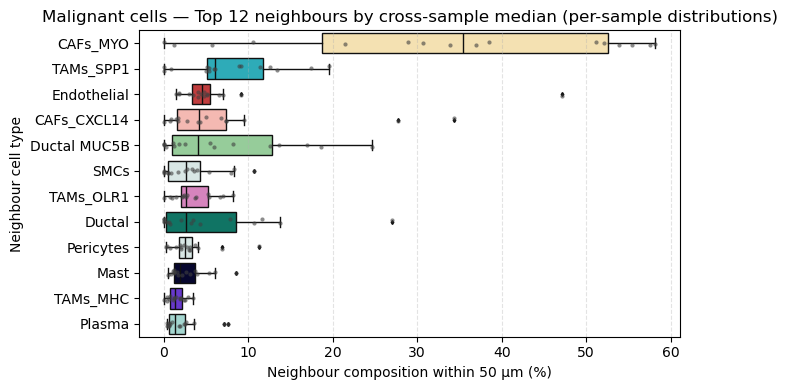

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

wide = pd.DataFrame(results_by_sample).T  # rows = samples, cols = neighbors (fractions)
wide = wide.fillna(0)

if any(col.endswith("_mean") for col in wide.columns):
    wide = wide[[c for c in wide.columns if c.endswith("_mean")]].copy()
    wide.columns = [c[:-5] for c in wide.columns]  # remove "_mean"

# Drop unwanted labels
wide = wide.drop(columns=[c for c in ["Unclassified", "Unassigned"] if c in wide.columns], errors="ignore")

# Convert to % 
wide_pct = wide * 100

# Compute median to rank/order
med_across_samples = wide_pct.median(axis=0).sort_values(ascending=False)

# Keep top cells only
topk = med_across_samples.head(min(12, len(med_across_samples))).index.tolist()

long = (
    wide_pct[topk]
    .reset_index()
    .rename(columns={"index": "sample"})
    .melt(id_vars="sample", var_name="neighbor", value_name="percent")
)

# Order neighbors by their cross-sample median
order = med_across_samples.loc[topk].index.tolist()

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=long, x="percent", y="neighbor",
    palette=manual_colors,
    order=order, fliersize=2, linewidth=1
)
sns.stripplot(
    data=long, x="percent", y="neighbor",
    order=order, color=".25", size=3, jitter=True, alpha=0.6
)
plt.xlabel("Neighbour composition within 50 µm (%)")
plt.ylabel("Neighbour cell type")
plt.title("Malignant cells — Top 12 neighbours by cross-sample median (per-sample distributions)")
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()